In [17]:
import requests
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
url = (
    "https://archive-api.open-meteo.com/v1/archive?"
    "latitude=28.6139&longitude=77.2090"
    "&start_date=2026-03-01"
    "&end_date=2026-03-15"
    "&hourly=temperature_2m,relative_humidity_2m,"
    "surface_pressure,wind_speed_10m"
)

response = requests.get(url)
data = response.json()

In [19]:
df = pd.DataFrame({
    "Time": data["hourly"]["time"],
    "Temperature": data["hourly"]["temperature_2m"],
    "Humidity": data["hourly"]["relative_humidity_2m"],
    "Pressure": data["hourly"]["surface_pressure"],
    "WindSpeed": data["hourly"]["wind_speed_10m"]
})

In [20]:
df.head()

,Time,Temperature,Humidity,Pressure,WindSpeed
0,2026-03-01T00:00,17.3,78,982.9,7.4
1,2026-03-01T01:00,17.2,77,983.5,6.7
2,2026-03-01T02:00,17.5,73,984.1,7.6
3,2026-03-01T03:00,19.7,63,985.2,6.1
4,2026-03-01T04:00,23.1,52,986.1,6.5


In [21]:
df["Weather_Class"] = np.where(
    df["Temperature"] >= 25,
    "Warm",
    "Cool"
)

In [22]:
print(df["Weather_Class"].value_counts())

Weather_Class
Warm    217
Cool    143
Name: count, dtype: int64


In [23]:
print(df.isnull().sum())

Time             0
Temperature      0
Humidity         0
Pressure         0
WindSpeed        0
Weather_Class    0
dtype: int64


In [24]:
df.drop("Time", axis=1, inplace=True)

In [25]:
encoder = LabelEncoder()

df["Weather_Class"] = encoder.fit_transform(df["Weather_Class"])

In [26]:
X = df.drop("Weather_Class", axis=1)

y = df["Weather_Class"]

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [28]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [29]:
svm = SVC(
    kernel="rbf",
    random_state=42
)

svm.fit(X_train, y_train)

SVC(random_state=42)

In [30]:
y_pred = svm.predict(X_test)

In [32]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

precision = precision_score(y_test, y_pred)
print("Precision:", precision)

recall = recall_score(y_test, y_pred)
print("Recall:", recall)

f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

print(classification_report(y_test, y_pred))

Accuracy: 0.9583333333333334
Precision: 0.9545454545454546
Recall: 0.9767441860465116
F1 Score: 0.9655172413793104
              precision    recall  f1-score   support

           0       0.96      0.93      0.95        29
           1       0.95      0.98      0.97        43

    accuracy                           0.96        72
   macro avg       0.96      0.95      0.96        72
weighted avg       0.96      0.96      0.96        72



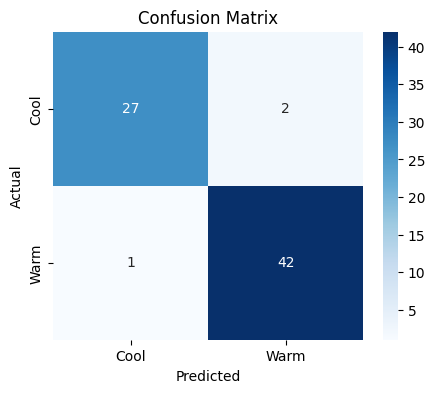

In [33]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt="d",
    xticklabels=["Cool","Warm"],
    yticklabels=["Cool","Warm"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()